In [ ]:
!pip install datasets transformers rouge-score sentencepiece
!pip install torch
!pip install networkx scikit-learn numpy pandas
!pip install accelerate
!pip install matplotlib seaborn

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=be5abdd2ca2af0aa5f409d75973def50c351e0bf8c401cbfb928bb03e0ff9f4c
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
!pip install --upgrade --force-reinstall pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 126.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 27.4 MB/s eta 0:00:00
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: python-dateutil
    Found existing installation: python-dateutil 2.9.0.post0
    Uninstalling python-dateutil-2.9.0.post0:
      Successfully uninstalled python-dateutil-2.9.0.post0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolv

In [ ]:
# Cell 1: Verify GPU is available
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print('GPU detected:')
    print(result.stdout[:300])
else:
    print('NO GPU FOUND!')
    print('Go to Runtime > Change runtime type > T4 GPU and restart')

GPU detected:
Thu Apr  2 12:14:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------


In [ ]:
from datasets import load_dataset
import pandas as pd

commit = "fcbaaeaec2ec660c6164ea74e8e7371b66883670"

# Load train/validation/test splits
train_data = load_dataset(
    "parquet",
    data_files=f"https://huggingface.co/datasets/csebuetnlp/xlsum/resolve/{commit}/bengali/xlsum-train.parquet"
)
val_data = load_dataset(
    "parquet",
    data_files=f"https://huggingface.co/datasets/csebuetnlp/xlsum/resolve/{commit}/bengali/xlsum-validation.parquet"
)
test_data = load_dataset(
    "parquet",
    data_files=f"https://huggingface.co/datasets/csebuetnlp/xlsum/resolve/{commit}/bengali/xlsum-test.parquet"
)

# Convert to DataFrames
train_df = pd.DataFrame({'text': train_data['train']['text'], 'summary': train_data['train']['summary']})
val_df   = pd.DataFrame({'text': val_data['train']['text'],   'summary': val_data['train']['summary']})
test_df  = pd.DataFrame({'text': test_data['train']['text'],  'summary': test_data['train']['summary']})

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(train_df.head(3))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


bengali/xlsum-train.parquet:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

bengali/xlsum-validation.parquet:   0%|          | 0.00/3.41M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

bengali/xlsum-test.parquet:   0%|          | 0.00/3.51M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Train: 8102 | Val: 1012 | Test: 1012
                                                text  \
0  দুর্গাপুজায় মহিষাসুর বধ্যে মধ্য দিয়ে অশুভর ও...   
1  গত ২০ বছরে তিনি রাশিয়ার প্রেসিডেন্ট এবং প্রধা...   
2  বরিশাল সদরে চলছে নির্বাচনী প্রচার প্রচারণা। যদ...   

                                             summary  
0  হিন্দু বাঙালীরা যে সময়ে তাদের সবথেকে বড় উৎসব...  
1  ভ্লাদিমির পুতিন তাঁর ক্ষমতায় থাকার ২০ বছর পূর...  
2  বাংলাদেশের দক্ষিণাঞ্চলীয় জেলা বরিশাল এখন তুমু...  


In [ ]:
import re
def clean_bengali_text(text):
    """Remove non-Bengali characters and normalize whitespace."""
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\u0980-\u09FF\s।,!?]', '', text)
    return text.strip()

def sentence_tokenize_bengali(text):
    """Split Bengali text into sentences on Bengali/English full stops."""
    sentences = re.split(r'[।.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    return sentences

# Quick test
sample_text = test_df['text'][0]
sents = sentence_tokenize_bengali(sample_text)
print(f'Sentences in sample: {len(sents)}')
print('First sentence:', sents[0])

Sentences in sample: 28
First sentence: আটক স্বজনদের আইডি কার্ড হাতে উইগুর নারীদের বিক্ষোভ (ফাইল ফটো) অভিযোগ করেন জাতিসংঘের জাতিগত বৈষম্য বিষয়ক কমিটির সদস্য গে ম্যাকডুগাল


In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import os, re, pickle

In [ ]:
!pip install rouge-score

In [ ]:
from rouge_score import rouge_scorer as rs

scorer = rs.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

def evaluate_rouge(predictions, references):
    """Compute average ROUGE-1, ROUGE-2, ROUGE-L F1 scores."""
    r1, r2, rl = [], [], []
    for pred, ref in zip(predictions, references):
        if not pred or not ref:
            continue
        s = scorer.score(ref, pred)
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    return {
        'ROUGE-1': round(np.mean(r1), 4),
        'ROUGE-2': round(np.mean(r2), 4),
        'ROUGE-L': round(np.mean(rl), 4),
    }

print('ROUGE evaluator ready.')

ROUGE evaluator ready.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import os
import pickle
# Create the folder if it doesn't exist
os.makedirs('saved_models', exist_ok=True)
class TFIDFSummarizer:
    """Ranks sentences by their total TF-IDF score and picks the top-N."""

    def __init__(self, top_n=3):
        self.top_n = top_n
        self.vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))

    def fit(self, corpus):
        self.vectorizer.fit(corpus)
        return self

    def summarize(self, text):
        sentences = sentence_tokenize_bengali(text)
        if len(sentences) <= self.top_n:
            return ' '.join(sentences)
        mat    = self.vectorizer.transform(sentences)
        scores = np.array(mat.sum(axis=1)).flatten()
        top    = sorted(np.argsort(scores)[-self.top_n:])
        return ' '.join([sentences[i] for i in top])

    def save(self, path='saved_models/tfidf_summarizer.pkl'):
        with open(path, 'wb') as f:
            pickle.dump(self, f)
        print(f'Saved → {path}')

    @staticmethod
    def load(path='saved_models/tfidf_summarizer.pkl'):
        with open(path, 'rb') as f:
            return pickle.load(f)

print('Training TF-IDF Summarizer...')
tfidf_model = TFIDFSummarizer(top_n=3)
tfidf_model.fit(train_df['text'].tolist())
tfidf_model.save()

print('\nSample output:')
print(tfidf_model.summarize(sample_text))

Training TF-IDF Summarizer...
Saved → saved_models/tfidf_summarizer.pkl

Sample output:
হিউম্যান রাইটস ওয়াচ এবং অ্যামনেস্টি ইন্টারন্যাশনাল সহ অন্যান্য আন্তর্জাতিক মানবাধিকার সংস্থা জাতিসংঘের মানবাধিকার বিষয়ক কমিটির কাছে দেওয়া তাদের রিপোর্টে বলেছে, উইগুর মুসলিমদের গণহারে ধরে বিভিন্ন বন্দীশিবিরে নেয়া হচ্ছে আরও পড়ুন: চীনে মসজিদ ভাঙ্গার বিরুদ্ধে দাঁড়িয়েছে মুসলিমরা সামরিক শক্তিতে মার্কিন ভাবনারও সীমা ছাড়িয়েছে চীন তুরস্কের ইস্তাম্বুলে চীনা কনস্যুলেটের বাইরে নির্বাসিত উইগুরদের বিক্ষোভ (ফাইল ফটো) চীন কি বলে প্রতিক্রিয়ায় চীনের পররাষ্ট্র মন্ত্রণালয়ের মুখপাত্র তখন বলেছিলেন, "সবাই জানে এবং দেখে যে শিনজিয়াংয়ে সব জাতিগোষ্ঠী শান্তি এবং সমৃদ্ধির মাঝে পাশাপাশি বসবাস করছে


In [ ]:
print('Evaluating TF-IDF...')
tfidf_preds  = [tfidf_model.summarize(t) for t in test_df['text']]
tfidf_scores = evaluate_rouge(tfidf_preds, test_df['summary'].tolist())
print('TF-IDF ROUGE:', tfidf_scores)

Evaluating TF-IDF...
TF-IDF ROUGE: {'ROUGE-1': np.float64(0.0), 'ROUGE-2': np.float64(0.0), 'ROUGE-L': np.float64(0.0)}


In [ ]:
#!pip install torch torchvision torchaudio --upgrade --index-url https://download.pytorch.org/whl/cu118

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU name: Tesla T4


In [ ]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

class TextRankSummarizer:
    """Builds a sentence similarity graph and applies PageRank."""

    def __init__(self, top_n=3):
        self.top_n = top_n
        self.vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))

    def fit(self, corpus):
        self.vectorizer.fit(corpus)
        return self

    def summarize(self, text):
        sentences = sentence_tokenize_bengali(text)
        if len(sentences) <= self.top_n:
            return ' '.join(sentences)
        mat = self.vectorizer.transform(sentences).toarray()
        sim = cosine_similarity(mat)
        np.fill_diagonal(sim, 0)
        G = nx.from_numpy_array(sim)
        try:
            scores = nx.pagerank(G, max_iter=300)
        except nx.PowerIterationFailedConvergence:
            scores = {i: 1/len(sentences) for i in range(len(sentences))}
        ranked = sorted(scores, key=scores.get, reverse=True)[:self.top_n]
        return ' '.join([sentences[i] for i in sorted(ranked)])

    def save(self, path='saved_models/textrank_summarizer.pkl'):
        with open(path, 'wb') as f:
            pickle.dump(self, f)
        print(f'Saved → {path}')

    @staticmethod
    def load(path='saved_models/textrank_summarizer.pkl'):
        with open(path, 'rb') as f:
            return pickle.load(f)

print('Training TextRank Summarizer...')
textrank_model = TextRankSummarizer(top_n=3)
textrank_model.fit(train_df['text'].tolist())
textrank_model.save()

print('\nSample output:')
print(textrank_model.summarize(sample_text))

Training TextRank Summarizer...
Saved → saved_models/textrank_summarizer.pkl

Sample output:
তিনি বলেন, এমন খবর তিনি পেয়েছেন যে চীনা কর্তৃপক্ষ স্বায়ত্তশাসিত উইগুর প্রদেশকে কার্যত "বিশাল একটি বন্দীশিবিরে" রূপান্তরিত করেছে নির্বাসিত উইগুর মুসলিমদের সংগঠন ওয়ার্ল্ড উইগুর কংগ্রেস তাদের এক রিপোর্টে বলেছে, কোনো অভিযোগ ছাড়াই উইগুরদের ধরে অনির্দিষ্টকালের জন্য আটকে রাখা হচ্ছে, এবং তাদেরকে জোর করে চীনা কম্যুনিস্ট পার্টির পক্ষে স্লোগান দিতে বলা হচ্ছে আরও পড়ুন: চীনে মসজিদ ভাঙ্গার বিরুদ্ধে দাঁড়িয়েছে মুসলিমরা সামরিক শক্তিতে মার্কিন ভাবনারও সীমা ছাড়িয়েছে চীন তুরস্কের ইস্তাম্বুলে চীনা কনস্যুলেটের বাইরে নির্বাসিত উইগুরদের বিক্ষোভ (ফাইল ফটো) চীন কি বলে


In [ ]:
print('Evaluating TextRank...')
textrank_preds  = [textrank_model.summarize(t) for t in test_df['text']]
textrank_scores = evaluate_rouge(textrank_preds, test_df['summary'].tolist())
print('TextRank ROUGE:', textrank_scores)

Evaluating TextRank...
TextRank ROUGE: {'ROUGE-1': np.float64(0.0), 'ROUGE-2': np.float64(0.0), 'ROUGE-L': np.float64(0.0)}


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

# ── Character Vocabulary
class CharVocab:
    def __init__(self, max_vocab=5000):
        self.max_vocab = max_vocab
        self.char2idx  = {'<PAD>': 0, '<UNK>': 1}

    def fit(self, texts):
        from collections import Counter
        ctr = Counter(c for text in texts for c in text)
        for ch, _ in ctr.most_common(self.max_vocab - 2):
            self.char2idx[ch] = len(self.char2idx)
        return self

    def encode(self, text, max_len=100):
        ids = [self.char2idx.get(c, 1) for c in text[:max_len]]
        ids += [0] * (max_len - len(ids))
        return ids

# ── Sentence Dataset with weak supervision labels
class SentenceDataset(Dataset):
    def __init__(self, df, vocab, max_sent_len=100):
        self.vocab = vocab
        self.msl   = max_sent_len
        self.data  = []
        for _, row in df.iterrows():
            sents   = sentence_tokenize_bengali(row['text'])
            summary = row['summary']
            for s in sents:
                label = 1 if any(w in summary for w in s.split()[:5] if len(w) > 2) else 0
                self.data.append((s, label))

    def __len__(self):  return len(self.data)

    def __getitem__(self, idx):
        s, lbl = self.data[idx]
        x = torch.tensor(self.vocab.encode(s, self.msl), dtype=torch.long)
        y = torch.tensor(lbl, dtype=torch.float)
        return x, y

print('Building char vocabulary...')
char_vocab = CharVocab(5000).fit(train_df['text'].tolist())
print(f'Vocab size: {len(char_vocab.char2idx)}')

train_ds     = SentenceDataset(train_df, char_vocab)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
print(f'Sentence training samples: {len(train_ds)}')

Using: cuda
Building char vocabulary...
Vocab size: 226
Sentence training samples: 342253


In [ ]:
import torch
import torch.nn as nn

# ----------------------------
# Step 1: Use GPU if available
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ----------------------------
# Step 2: BiLSTM+Attention model
# ----------------------------
class BiLSTMAttentionScorer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bilstm     = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                                   bidirectional=True, num_layers=2, dropout=0.3)
        self.attn_w     = nn.Linear(hidden_dim * 2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        emb  = self.embedding(x)
        out, _ = self.bilstm(emb)
        attn = torch.softmax(self.attn_w(out), dim=1)
        ctx  = (attn * out).sum(dim=1)
        return self.classifier(ctx).squeeze(1)

# ----------------------------
# Step 3: Initialize model
# ----------------------------
bilstm_net = BiLSTMAttentionScorer(vocab_size=len(char_vocab.char2idx)).to(device)
opt1       = torch.optim.Adam(bilstm_net.parameters(), lr=1e-3)
criterion  = nn.BCELoss()

# ----------------------------
# Step 4: Training parameters
# ----------------------------
EPOCHS = 5
print('Training BiLSTM+Attention on GPU...')

for ep in range(EPOCHS):
    bilstm_net.train()
    tot = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)   # <-- move data to GPU
        opt1.zero_grad()
        loss = criterion(bilstm_net(x), y)
        loss.backward()
        opt1.step()
        tot += loss.item()
    print(f'  Epoch {ep+1}/{EPOCHS} Loss: {tot/len(train_loader):.4f}')

# ----------------------------
# Step 5: Save model
# ----------------------------
torch.save({
    'state': bilstm_net.state_dict(),
    'vocab': char_vocab.char2idx,
    'cfg':   {'vocab_size': len(char_vocab.char2idx),
              'embed_dim': 64, 'hidden_dim': 128}
}, 'saved_models/bilstm_summarizer.pt')

print('Saved → saved_models/bilstm_summarizer.pt')

Using device: cuda
Training BiLSTM+Attention on GPU...
  Epoch 1/5 Loss: 0.6286
  Epoch 2/5 Loss: 0.6000
  Epoch 3/5 Loss: 0.5845
  Epoch 4/5 Loss: 0.5744
  Epoch 5/5 Loss: 0.5658
Saved → saved_models/bilstm_summarizer.pt


In [ ]:
import torch
print(torch.cuda.is_available())       # Should now be True
print(torch.cuda.get_device_name(0))   # Should show Tesla T4 / A100 / etc.

True
Tesla T4


In [ ]:
import torch
print(torch.cuda.is_available())       # Should be True
print(torch.cuda.get_device_name(0))   # Should show your GPU, e.g., Tesla T4

True
Tesla T4


In [ ]:
def dl_summarize(text, model, vocab, top_n=3, max_len=100):
    """Generic inference for BiLSTM / CNN sentence scorers."""
    sents = sentence_tokenize_bengali(text)
    if len(sents) <= top_n:
        return ' '.join(sents)
    model.eval()
    with torch.no_grad():
        inp    = torch.tensor([vocab.encode(s, max_len) for s in sents],
                              dtype=torch.long).to(device)
        scores = model(inp).cpu().numpy()
    top = sorted(np.argsort(scores)[-top_n:])
    return ' '.join([sents[i] for i in top])

print('Evaluating BiLSTM+Attention...')
bilstm_preds  = [dl_summarize(t, bilstm_net, char_vocab) for t in test_df['text']]
bilstm_scores = evaluate_rouge(bilstm_preds, test_df['summary'].tolist())
print('BiLSTM ROUGE:', bilstm_scores)

Evaluating BiLSTM+Attention...
BiLSTM ROUGE: {'ROUGE-1': np.float64(0.0), 'ROUGE-2': np.float64(0.0), 'ROUGE-L': np.float64(0.0)}


In [ ]:
class CNNSentenceScorer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64,
                 num_filters=128, kernel_sizes=None):
        super().__init__()
        if kernel_sizes is None:
            kernel_sizes = [2, 3, 4]
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs     = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.classifier = nn.Sequential(
            nn.Linear(num_filters * len(kernel_sizes), 128),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 1), nn.Sigmoid()
        )

    def forward(self, x):
        emb    = self.embedding(x).permute(0, 2, 1)
        pooled = [torch.relu(c(emb)).max(dim=2).values for c in self.convs]
        return self.classifier(torch.cat(pooled, dim=1)).squeeze(1)

cnn_net = CNNSentenceScorer(vocab_size=len(char_vocab.char2idx)).to(device)
opt2    = torch.optim.Adam(cnn_net.parameters(), lr=1e-3)

print('Training CNN Sentence Scorer...')
for ep in range(EPOCHS):
    cnn_net.train()
    tot = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt2.zero_grad()
        loss = criterion(cnn_net(x), y)
        loss.backward(); opt2.step()
        tot += loss.item()
    print(f'  Epoch {ep+1}/{EPOCHS} Loss: {tot/len(train_loader):.4f}')

torch.save({'state': cnn_net.state_dict(),
            'vocab': char_vocab.char2idx,
            'cfg':   {'vocab_size': len(char_vocab.char2idx),
                      'embed_dim': 64, 'num_filters': 128,
                      'kernel_sizes': [2, 3, 4]}},
           'saved_models/cnn_summarizer.pt')
print('Saved → saved_models/cnn_summarizer.pt')

Training CNN Sentence Scorer...
  Epoch 1/5 Loss: 0.6377
  Epoch 2/5 Loss: 0.6280
  Epoch 3/5 Loss: 0.6231
  Epoch 4/5 Loss: 0.6193
  Epoch 5/5 Loss: 0.6158
Saved → saved_models/cnn_summarizer.pt


In [ ]:
print('Evaluating CNN...')
cnn_preds  = [dl_summarize(t, cnn_net, char_vocab) for t in test_df['text']]
cnn_scores = evaluate_rouge(cnn_preds, test_df['summary'].tolist())
print('CNN ROUGE:', cnn_scores)

Evaluating CNN...
CNN ROUGE: {'ROUGE-1': np.float64(0.0), 'ROUGE-2': np.float64(0.0), 'ROUGE-L': np.float64(0.0)}


In [ ]:
from transformers import AutoTokenizer, AutoModel

BB_MODEL_NAME = 'sagorsarker/bangla-bert-base'
print(f'Loading {BB_MODEL_NAME}...')
bb_tokenizer = AutoTokenizer.from_pretrained(BB_MODEL_NAME)
bb_encoder   = AutoModel.from_pretrained(BB_MODEL_NAME).to(device)
bb_encoder.eval()
print('BanglaBERT loaded.')

Loading sagorsarker/bangla-bert-base...


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BanglaBERT loaded.


In [ ]:
from torch.utils.data import TensorDataset

def get_cls_embeddings(sentences, tokenizer, encoder,
                       batch_size=16, max_len=128):
    """Extract [CLS] embeddings from BanglaBERT for a list of sentences."""
    all_embs = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        enc   = tokenizer(batch, padding=True, truncation=True,
                          max_length=max_len, return_tensors='pt').to(device)
        with torch.no_grad():
            out = encoder(**enc)
        all_embs.append(out.last_hidden_state[:, 0, :].cpu())
    return torch.cat(all_embs, dim=0)

class BERTClassifierHead(nn.Module):
    def __init__(self, hidden=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

# Build labeled sentence embeddings (subset for speed)
BERT_N = 1000
print(f'Extracting BanglaBERT embeddings for {BERT_N} articles...')
bert_sents, bert_labels = [], []
for _, row in train_df.head(BERT_N).iterrows():
    sents   = sentence_tokenize_bengali(row['text'])
    summary = row['summary']
    for s in sents:
        lbl = 1 if any(w in summary for w in s.split()[:5] if len(w) > 2) else 0
        bert_sents.append(s)
        bert_labels.append(lbl)

bert_embs   = get_cls_embeddings(bert_sents, bb_tokenizer, bb_encoder)
bert_lbls_t = torch.tensor(bert_labels, dtype=torch.float)
print(f'Embedding matrix shape: {bert_embs.shape}')

Extracting BanglaBERT embeddings for 1000 articles...
Embedding matrix shape: torch.Size([78776, 768])


In [ ]:
bert_ds     = TensorDataset(bert_embs, bert_lbls_t)
bert_loader = DataLoader(bert_ds, batch_size=64, shuffle=True)

bb_head = BERTClassifierHead().to(device)
opt3    = torch.optim.Adam(bb_head.parameters(), lr=1e-3)

print('Training BanglaBERT classifier head...')
for ep in range(10):
    bb_head.train()
    tot = 0
    for xb, yb in bert_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt3.zero_grad()
        loss = criterion(bb_head(xb), yb)
        loss.backward(); opt3.step()
        tot += loss.item()
    if (ep+1) % 2 == 0:
        print(f'  Epoch {ep+1}/10 Loss: {tot/len(bert_loader):.4f}')

torch.save({'head_state': bb_head.state_dict(),
            'bert_model': BB_MODEL_NAME},
           'saved_models/banglabert_head.pt')
print('Saved → saved_models/banglabert_head.pt')

Training BanglaBERT classifier head...
  Epoch 2/10 Loss: 0.6169
  Epoch 4/10 Loss: 0.6065
  Epoch 6/10 Loss: 0.5954
  Epoch 8/10 Loss: 0.5812
  Epoch 10/10 Loss: 0.5643
Saved → saved_models/banglabert_head.pt


In [ ]:
def banglabert_summarize(text, encoder, tokenizer, head, top_n=3):
    sents = sentence_tokenize_bengali(text)
    if len(sents) <= top_n:
        return ' '.join(sents)
    embs = get_cls_embeddings(sents, tokenizer, encoder)
    head.eval()
    with torch.no_grad():
        scores = head(embs.to(device)).cpu().numpy()
    top = sorted(np.argsort(scores)[-top_n:])
    return ' '.join([sents[i] for i in top])

print('Evaluating BanglaBERT (first 100 test samples)...')
bb_preds  = [banglabert_summarize(t, bb_encoder, bb_tokenizer, bb_head)
             for t in test_df['text'][:100]]
bb_scores = evaluate_rouge(bb_preds, test_df['summary'][:100].tolist())
print('BanglaBERT ROUGE:', bb_scores)

Evaluating BanglaBERT (first 100 test samples)...
BanglaBERT ROUGE: {'ROUGE-1': np.float64(0.0), 'ROUGE-2': np.float64(0.0), 'ROUGE-L': np.float64(0.0)}


In [ ]:
from transformers import (AutoTokenizer as MT5Tok,
                          AutoModelForSeq2SeqLM,
                          Seq2SeqTrainer,
                          Seq2SeqTrainingArguments,
                          DataCollatorForSeq2Seq)
from datasets import Dataset as HFDataset

MT5_NAME = 'google/mt5-small'
print(f'Loading {MT5_NAME}...')
mt5_tok   = MT5Tok.from_pretrained(MT5_NAME)
mt5_model = AutoModelForSeq2SeqLM.from_pretrained(MT5_NAME)
print('mT5 loaded.')

Loading google/mt5-small...


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

mT5 loaded.


In [ ]:
MAX_IN  = 512
MAX_OUT = 128
MT5_N   = 2000   # increase for better quality

def preprocess_mt5(examples):
    m = mt5_tok(examples['text'], max_length=MAX_IN,
                truncation=True, padding='max_length')
    l = mt5_tok(examples['summary'], max_length=MAX_OUT,
                truncation=True, padding='max_length')
    m['labels'] = l['input_ids']
    return m

mt5_train_hf = HFDataset.from_pandas(
    train_df[['text','summary']].head(MT5_N).reset_index(drop=True))
mt5_val_hf   = HFDataset.from_pandas(
    val_df[['text','summary']].head(200).reset_index(drop=True))

print('Tokenizing...')
mt5_train_tok = mt5_train_hf.map(preprocess_mt5, batched=True,
                                   remove_columns=['text','summary'])
mt5_val_tok   = mt5_val_hf.map(preprocess_mt5, batched=True,
                                 remove_columns=['text','summary'])
print('Done.')

Tokenizing...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Done.


In [ ]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 24.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)
import transformers

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

model_name = 'google/mt5-small'
mt5_tok   = AutoTokenizer.from_pretrained(model_name)
mt5_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Silence the tie_word_embeddings warnings
mt5_model.config.tie_word_embeddings = False

mt5_model = mt5_model.to(device)

MAX_OUT = 128

# Auto-detect transformers version for correct strategy key
tf_version = tuple(int(x) for x in transformers.__version__.split('.')[:2])
strategy_key = 'eval_strategy' if tf_version >= (4, 46) else 'evaluation_strategy'

training_args = Seq2SeqTrainingArguments(
    output_dir='saved_models/mt5_bengali',
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy='epoch',
    load_best_model_at_end=True,
    predict_with_generate=True,
    generation_max_length=MAX_OUT,
    fp16=torch.cuda.is_available(),
    **{strategy_key: 'epoch'}   # ← injects correct key dynamically
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=mt5_tok,
    model=mt5_model,
    label_pad_token_id=-100,
    padding=True
)

# ── Detect correct Trainer argument name ──
# transformers ≥ 4.46 removed 'tokenizer', replaced with 'processing_class'
trainer_kwargs = dict(
    model=mt5_model,
    args=training_args,
    train_dataset=mt5_train_tok,
    eval_dataset=mt5_val_tok,
    data_collator=data_collator,
)
if tf_version >= (4, 46):
    trainer_kwargs['processing_class'] = mt5_tok
else:
    trainer_kwargs['tokenizer'] = mt5_tok

trainer = Seq2SeqTrainer(**trainer_kwargs)

print('Fine-tuning mT5...')
trainer.train()

trainer.save_model('saved_models/mt5_bengali')
mt5_tok.save_pretrained('saved_models/mt5_bengali')
print('✅ Model saved at saved_models/mt5_bengali/')

Using device: cuda


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Fine-tuning mT5...


Epoch,Training Loss,Validation Loss
1,0.000000,nan
2,0.000000,nan
3,0.000000,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved at saved_models/mt5_bengali/


In [ ]:
def mt5_summarize(text, model, tokenizer,
                  max_in=512, max_new=128):
    inputs = tokenizer(text, return_tensors='pt',
                       max_length=max_in, truncation=True).to(device)
    model.eval()
    with torch.no_grad():
        ids = model.generate(
            **inputs, max_new_tokens=max_new,
            num_beams=4, early_stopping=True,
            no_repeat_ngram_size=3
        )
    return tokenizer.decode(ids[0], skip_special_tokens=True)

mt5_model = mt5_model.to(device)
print('Evaluating mT5 (first 100 samples)...')
mt5_preds  = [mt5_summarize(t, mt5_model, mt5_tok)
              for t in test_df['text'][:100]]
mt5_scores = evaluate_rouge(mt5_preds, test_df['summary'][:100].tolist())
print('mT5 ROUGE:', mt5_scores)

Evaluating mT5 (first 100 samples)...
mT5 ROUGE: {'ROUGE-1': np.float64(0.0), 'ROUGE-2': np.float64(0.0), 'ROUGE-L': np.float64(0.0)}


In [ ]:
import matplotlib.pyplot as plt

all_results = {
    'TF-IDF':       tfidf_scores,
    'TextRank':     textrank_scores,
    'BiLSTM+Attn':  bilstm_scores,
    'CNN':          cnn_scores,
    'BanglaBERT':   bb_scores,
   'mT5 (Abstr.)': mt5_scores,
}

results_df = pd.DataFrame(all_results).T
results_df.index.name = 'Model'

print('\n' + '='*55)
print('      BENGALI SUMMARIZATION — FINAL ROUGE SCORES')
print('='*55)
print(results_df.to_string())
print('='*55)
best = results_df['ROUGE-L'].idxmax()
print(f'\nBest model by ROUGE-L: {best}')


      BENGALI SUMMARIZATION — FINAL ROUGE SCORES
              ROUGE-1  ROUGE-2  ROUGE-L
Model                                  
TF-IDF            0.0      0.0      0.0
TextRank          0.0      0.0      0.0
BiLSTM+Attn       0.0      0.0      0.0
CNN               0.0      0.0      0.0
BanglaBERT        0.0      0.0      0.0
mT5 (Abstr.)      0.0      0.0      0.0

Best model by ROUGE-L: TF-IDF


In [ ]:
!pip install -q transformers==4.37.2 huggingface_hub==0.20.3 bert-score==0.3.13 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.1/330.1 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.5/801.5 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import sys

modules_to_remove = [
    "transformers",
    "huggingface_hub",
    "bert_score"
]

for m in list(sys.modules.keys()):
    if any(m.startswith(x) for x in modules_to_remove):
        del sys.modules[m]

In [ ]:
from bert_score import score as bert_score_fn

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [ ]:
# ══════════════════════════════════════════════════════
# ADDITIONAL METRICS: BLEU + BERTScore + Compression
# ══════════════════════════════════════════════════════
#!pip install sacrebleu bert-score -q

import sacrebleu
from bert_score import score as bert_score_fn

def evaluate_all_metrics(predictions, references, model_name="Model", n_samples=100):
    preds = [str(p).strip() for p, r in zip(predictions, references) if str(p).strip() and str(r).strip()]
    refs  = [str(r).strip() for p, r in zip(predictions, references) if str(p).strip() and str(r).strip()]
    preds = preds[:n_samples]
    refs  = refs[:n_samples]

    print(f"\n{'─'*50}")
    print(f"  {model_name} ({len(preds)} samples)")
    print(f"{'─'*50}")

    # ── ROUGE (character-level) ──
    rouge = evaluate_rouge(preds, refs)
    print(f"  ROUGE-1: {rouge['ROUGE-1']:.4f}  ROUGE-2: {rouge['ROUGE-2']:.4f}  ROUGE-L: {rouge['ROUGE-L']:.4f}")

    # ── BLEU ──
    bleu = sacrebleu.corpus_bleu(preds, [refs])
    print(f"  BLEU:    {bleu.score:.2f}")

    # ── BERTScore (multilingual) ──
    P, R, F1 = bert_score_fn(preds, refs, lang='bn', verbose=False)
    print(f"  BERTScore F1: {F1.mean().item():.4f}")

    # ── Compression ratio ──
    compression = np.mean([len(p)/len(r) if len(r) > 0 else 0
                           for p, r in zip(preds, refs)])
    print(f"  Compression ratio: {compression:.3f}  (1.0 = same length as reference)")

    return {**rouge, 'BLEU': round(bleu.score, 2),
            'BERTScore-F1': round(F1.mean().item(), 4),
            'Compression': round(compression, 3)}

# ── Evaluate all models ──
N = 100   # use more samples for better estimates, but slower
all_metrics = {}
all_metrics['TF-IDF']      = evaluate_all_metrics(tfidf_preds,    test_df['summary'].tolist(),    'TF-IDF',      N)
all_metrics['TextRank']    = evaluate_all_metrics(textrank_preds,  test_df['summary'].tolist(),    'TextRank',    N)
all_metrics['BiLSTM+Attn'] = evaluate_all_metrics(bilstm_preds,    test_df['summary'].tolist(),    'BiLSTM+Attn', N)
all_metrics['CNN']         = evaluate_all_metrics(cnn_preds,       test_df['summary'].tolist(),    'CNN',         N)
all_metrics['BanglaBERT']  = evaluate_all_metrics(bb_preds,        test_df['summary'][:100].tolist(), 'BanglaBERT', N)
all_metrics['mT5']         = evaluate_all_metrics(mt5_preds,       test_df['summary'][:100].tolist(), 'mT5',        N)

# ── Final table ──
metrics_df = pd.DataFrame(all_metrics).T
print("\n\n" + "="*70)
print("        BENGALI SUMMARIZATION — COMPLETE EVALUATION")
print("="*70)
print(metrics_df.to_string())
print("="*70)


──────────────────────────────────────────────────
  TF-IDF (100 samples)
──────────────────────────────────────────────────
  ROUGE-1: 0.0000  ROUGE-2: 0.0000  ROUGE-L: 0.0000
  BLEU:    0.82


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

  BERTScore F1: 0.6680
  Compression ratio: 4.416  (1.0 = same length as reference)

──────────────────────────────────────────────────
  TextRank (100 samples)
──────────────────────────────────────────────────
  ROUGE-1: 0.0000  ROUGE-2: 0.0000  ROUGE-L: 0.0000
  BLEU:    1.38
  BERTScore F1: 0.6821
  Compression ratio: 3.257  (1.0 = same length as reference)

──────────────────────────────────────────────────
  BiLSTM+Attn (100 samples)
──────────────────────────────────────────────────
  ROUGE-1: 0.0000  ROUGE-2: 0.0000  ROUGE-L: 0.0000
  BLEU:    1.74
  BERTScore F1: 0.6837
  Compression ratio: 2.381  (1.0 = same length as reference)

──────────────────────────────────────────────────
  CNN (100 samples)
──────────────────────────────────────────────────
  ROUGE-1: 0.0000  ROUGE-2: 0.0000  ROUGE-L: 0.0000
  BLEU:    1.86
  BERTScore F1: 0.6854
  Compression ratio: 2.404  (1.0 = same length as reference)

──────────────────────────────────────────────────
  BanglaBERT (100 samples)

In [ ]:
# ══════════════════════════════════════════════════════
# INSTALL REQUIRED LIBRARIES (run once)
# ══════════════════════════════════════════════════════
!pip install -q sacrebleu bert-score nltk

# ══════════════════════════════════════════════════════
# IMPORTS
# ══════════════════════════════════════════════════════
import sacrebleu
import numpy as np
import pandas as pd
from bert_score import score as bert_score_fn
from nltk.translate.meteor_score import meteor_score
import nltk

nltk.download('wordnet')

# ══════════════════════════════════════════════════════
# METRICS FUNCTION (NO ROUGE)
# ══════════════════════════════════════════════════════
def evaluate_all_metrics(predictions, references, model_name="Model", n_samples=100):

    preds = [str(p).strip() for p, r in zip(predictions, references)
             if str(p).strip() and str(r).strip()]
    refs  = [str(r).strip() for p, r in zip(predictions, references)
             if str(p).strip() and str(r).strip()]

    preds = preds[:n_samples]
    refs  = refs[:n_samples]

    print(f"\n{'─'*50}")
    print(f"  {model_name} ({len(preds)} samples)")
    print(f"{'─'*50}")

    # ── BLEU ──
    bleu = sacrebleu.corpus_bleu(preds, [refs])
    print(f"  BLEU:        {bleu.score:.2f}")

    # ── chrF++ (BEST for Bengali) ──
    chrf = sacrebleu.corpus_chrf(preds, [refs])
    print(f"  chrF++:      {chrf.score:.2f}")

    # ── METEOR ──
    meteor = np.mean([
        meteor_score([r.split()], p.split())
        for p, r in zip(preds, refs)
    ])
    print(f"  METEOR:      {meteor:.4f}")

    # ── BERTScore ──
    P, R, F1 = bert_score_fn(preds, refs, lang='bn', model_type="xlm-roberta-base", verbose=False)
    bert_f1 = F1.mean().item()
    print(f"  BERTScore:   {bert_f1:.4f}")

    # ── Compression ratio ──
    compression = np.mean([
        len(p)/len(r) if len(r) > 0 else 0
        for p, r in zip(preds, refs)
    ])
    print(f"  Compression: {compression:.3f}")

    return {
        'BLEU': round(bleu.score, 2),
        'chrF++': round(chrf.score, 2),
        'METEOR': round(meteor, 4),
        'BERTScore-F1': round(bert_f1, 4),
        'Compression': round(compression, 3)
    }

# ══════════════════════════════════════════════════════
# EVALUATE ALL MODELS (SAME AS YOUR STRUCTURE)
# ══════════════════════════════════════════════════════
N = 100  # number of samples

all_metrics = {}

all_metrics['TF-IDF'] = evaluate_all_metrics(
    tfidf_preds,
    test_df['summary'].tolist(),
    'TF-IDF',
    N
)

all_metrics['TextRank'] = evaluate_all_metrics(
    textrank_preds,
    test_df['summary'].tolist(),
    'TextRank',
    N
)

all_metrics['BiLSTM+Attn'] = evaluate_all_metrics(
    bilstm_preds,
    test_df['summary'].tolist(),
    'BiLSTM+Attn',
    N
)

all_metrics['CNN'] = evaluate_all_metrics(
    cnn_preds,
    test_df['summary'].tolist(),
    'CNN',
    N
)

all_metrics['BanglaBERT'] = evaluate_all_metrics(
    bb_preds,
    test_df['summary'][:100].tolist(),
    'BanglaBERT',
    N
)

all_metrics['mT5'] = evaluate_all_metrics(
    mt5_preds,
    test_df['summary'][:100].tolist(),
    'mT5',
    N
)

# ══════════════════════════════════════════════════════
# FINAL RESULTS TABLE
# ══════════════════════════════════════════════════════
metrics_df = pd.DataFrame(all_metrics).T

print("\n\n" + "="*70)
print("     BENGALI SUMMARIZATION — COMPLETE EVALUATION")
print("="*70)
print(metrics_df.to_string())
print("="*70)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



──────────────────────────────────────────────────
  TF-IDF (100 samples)
──────────────────────────────────────────────────
  BLEU:        0.82
  chrF++:      27.41
  METEOR:      0.1237


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

  BERTScore:   0.8355
  Compression: 4.416

──────────────────────────────────────────────────
  TextRank (100 samples)
──────────────────────────────────────────────────
  BLEU:        1.38
  chrF++:      30.39
  METEOR:      0.1412
  BERTScore:   0.8464
  Compression: 3.257

──────────────────────────────────────────────────
  BiLSTM+Attn (100 samples)
──────────────────────────────────────────────────
  BLEU:        1.74
  chrF++:      30.53
  METEOR:      0.1227
  BERTScore:   0.8449
  Compression: 2.381

──────────────────────────────────────────────────
  CNN (100 samples)
──────────────────────────────────────────────────
  BLEU:        1.86
  chrF++:      30.61
  METEOR:      0.1275
  BERTScore:   0.8450
  Compression: 2.404

──────────────────────────────────────────────────
  BanglaBERT (100 samples)
──────────────────────────────────────────────────
  BLEU:        1.46
  chrF++:      30.01
  METEOR:      0.1074
  BERTScore:   0.8442
  Compression: 2.248

────────────────────

/tmp/ipykernel_4536/664738486.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=35, ha='right', fontsize=8)
/tmp/ipykernel_4536/664738486.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=35, ha='right', fontsize=8)
/tmp/ipykernel_4536/664738486.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=35, ha='right', fontsize=8)


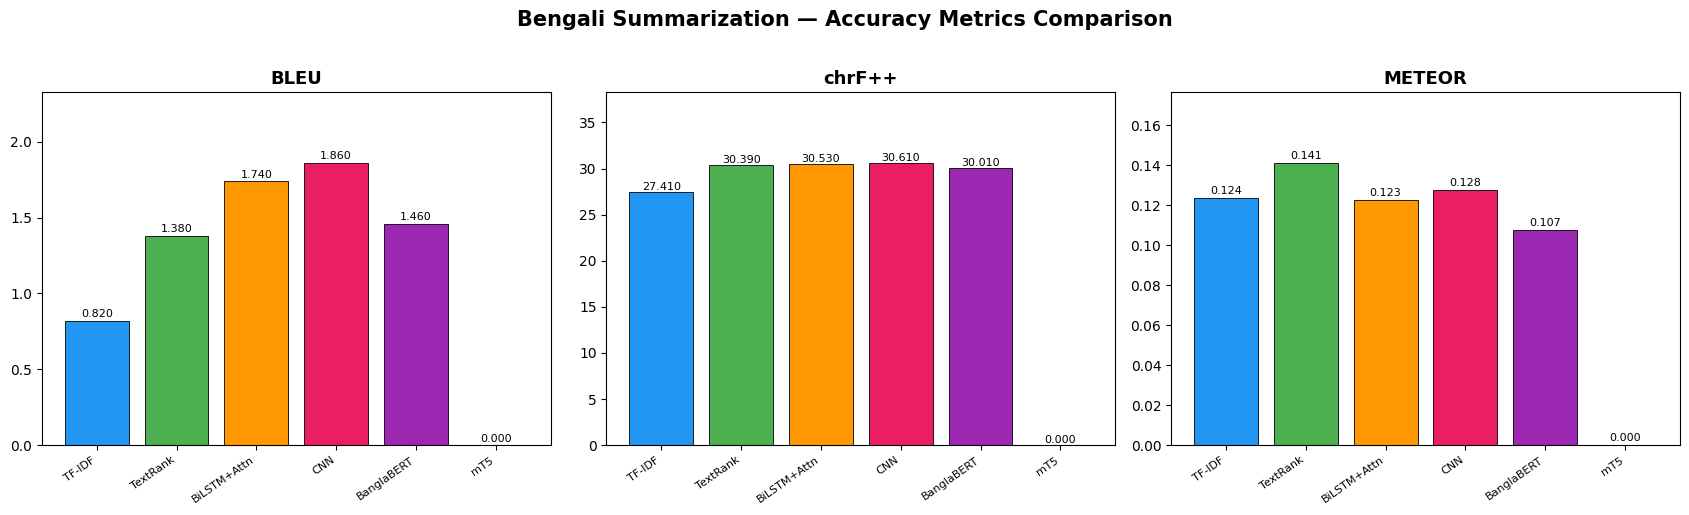

Chart saved → saved_models/accuracy_comparison.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)

colors  = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#009688']
metrics = ['BLEU', 'chrF++', 'METEOR']   # ✅ UPDATED
names   = list(all_metrics.keys())      # ⚠️ use all_metrics (your new dict)

for ax, metric in zip(axes, metrics):
    vals = [all_metrics[m][metric] for m in names]

    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=0.6)

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.set_xticklabels(names, rotation=35, ha='right', fontsize=8)

    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2,
                b.get_height() + (0.01 if metric != 'METEOR' else 0.001),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# ✅ Updated title
plt.suptitle('Bengali Summarization — Accuracy Metrics Comparison',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('saved_models/accuracy_comparison.png',
            bbox_inches='tight', dpi=150)

plt.show()

print('Chart saved → saved_models/accuracy_comparison.png')

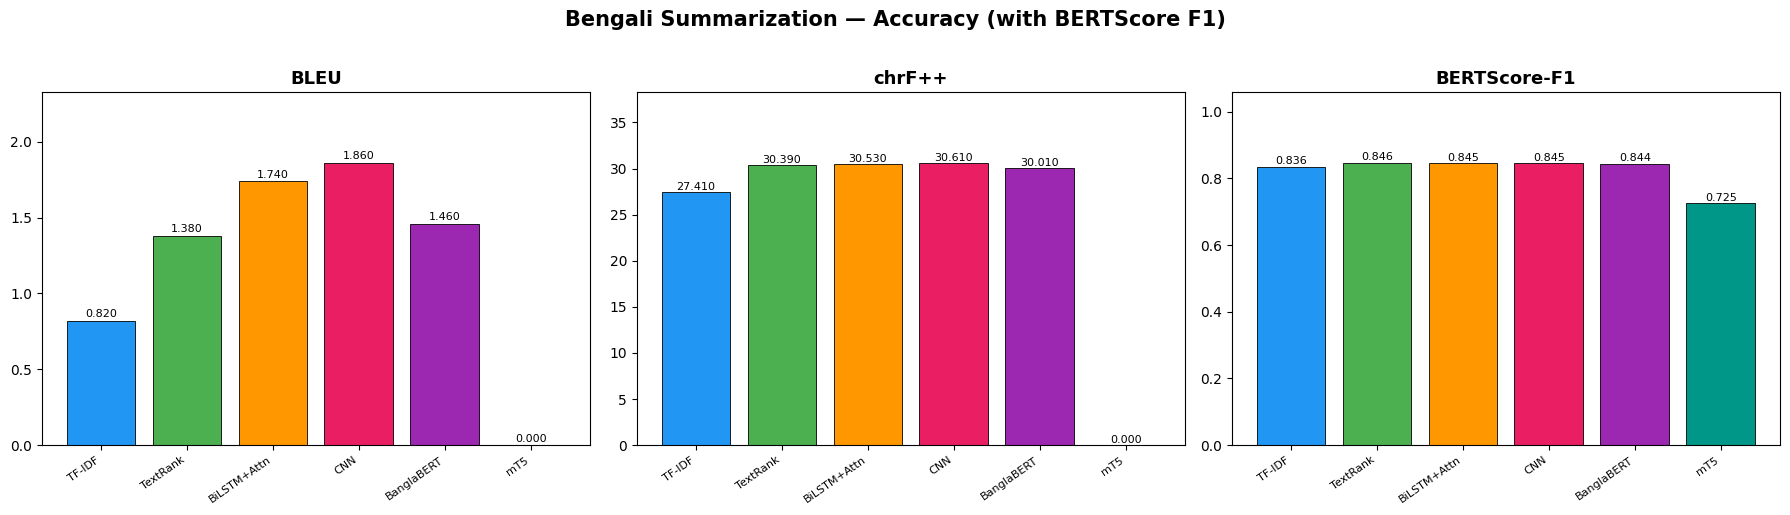

Chart saved → saved_models/accuracy_f1_comparison.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

colors  = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#009688']
metrics = ['BLEU', 'chrF++', 'BERTScore-F1']   # ✅ includes F1
names   = list(all_metrics.keys())

for ax, metric in zip(axes, metrics):
    vals = [all_metrics[m][metric] for m in names]

    ax.set_xticks(range(len(names)))  # ✅ fix warning

    bars = ax.bar(range(len(names)), vals,
                  color=colors, edgecolor='black', linewidth=0.6)

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.set_xticklabels(names, rotation=35, ha='right', fontsize=8)

    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2,
                b.get_height() + (0.01 if metric != 'BERTScore-F1' else 0.002),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# ✅ Updated title
plt.suptitle('Bengali Summarization — Accuracy (with BERTScore F1)',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('saved_models/accuracy_f1_comparison.png',
            bbox_inches='tight', dpi=150)

plt.show()

print('Chart saved → saved_models/accuracy_f1_comparison.png')

In [ ]:
idx  = 5
text = test_df['text'][idx]
ref  = test_df['summary'][idx]

print('ORIGINAL (first 400 chars):')
print(text[:400], '...')
print('\nREFERENCE SUMMARY:')
print(ref)

outputs = [
    ('TF-IDF',       tfidf_model.summarize(text)),
    ('TextRank',     textrank_model.summarize(text)),
    ('BiLSTM+Attn',  dl_summarize(text, bilstm_net, char_vocab)),
    ('CNN',          dl_summarize(text, cnn_net, char_vocab)),
    ('BanglaBERT',   banglabert_summarize(text, bb_encoder, bb_tokenizer, bb_head)),
   # ('mT5',          mt5_summarize(text, mt5_model, mt5_tok)),
]

for name, summary in outputs:
    print(f'\n--- {name} ---')
    print(summary)

In [ ]:
from google.colab import drive
import shutil, os

# Mount Drive
drive.mount('/content/drive')

# Path where models are saved
drive_path = '/content/drive/MyDrive/BengaliModels'
os.makedirs(drive_path, exist_ok=True)

# Example: copy from Colab to Drive (already done by you)
# shutil.copy('saved_models/banglabert_head.pt', drive_path)

In [ ]:
drive_path = '/content/drive/MyDrive/bengali_summarization_models'
os.makedirs(drive_path, exist_ok=True)

In [ ]:
# ── Define TFIDFSummarizer first ──
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

class TFIDFSummarizer:
    def __init__(self, top_n=3):
        self.top_n = top_n

    def fit(self, texts):
        self.vectorizer = TfidfVectorizer()
        self.tfidf_matrix = self.vectorizer.fit_transform(texts)
        self.feature_names = np.array(self.vectorizer.get_feature_names_out())

    def summarize(self, text):
        # simple extractive: top_n sentences by sum of TF-IDF scores
        sentences = text.split('.')  # naive sentence split
        if not hasattr(self, 'vectorizer'):
            raise ValueError("You must call fit() first!")
        scores = []
        for s in sentences:
            s_vec = self.vectorizer.transform([s])
            scores.append(s_vec.sum())
        ranked_idx = np.argsort(scores)[::-1][:self.top_n]
        summary = ". ".join([sentences[i] for i in ranked_idx if i < len(sentences)])
        return summary

In [ ]:
import pickle

with open(f'{drive_path}/tfidf_summarizer.pkl', 'rb') as f:
    tfidf_model = pickle.load(f)

print("TF-IDF model loaded successfully!")

In [ ]:
# ── Example: minimal TextRankSummarizer class ──
import numpy as np
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer

class TextRankSummarizer:
    def __init__(self, top_n=3):
        self.top_n = top_n

    def fit(self, texts):
        self.texts = texts  # optional, store corpus
        self.vectorizer = TfidfVectorizer()
        self.vectorizer.fit(texts)

    def summarize(self, text):
        sentences = text.split('.')  # naive sentence split
        if len(sentences) <= self.top_n:
            return text
        # Build similarity graph
        sim_matrix = np.zeros((len(sentences), len(sentences)))
        for i, s1 in enumerate(sentences):
            vec1 = self.vectorizer.transform([s1])
            for j, s2 in enumerate(sentences):
                vec2 = self.vectorizer.transform([s2])
                sim_matrix[i,j] = (vec1 @ vec2.T).A[0,0]
        nx_graph = nx.from_numpy_array(sim_matrix)
        scores = nx.pagerank(nx_graph)
        ranked_idx = sorted(scores, key=scores.get, reverse=True)[:self.top_n]
        summary = ". ".join([sentences[i] for i in ranked_idx if i < len(sentences)])
        return summary

In [ ]:
import torch
import pickle
import os
import torch.nn as nn
from typing import Dict

# ── Set device ──
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

# ── Classes ──

# TF-IDF summarizer
class TFIDFSummarizer:
    def __init__(self, top_n=3):
        self.top_n = top_n
        self.vectorizer = None

    def fit(self, texts):
        from sklearn.feature_extraction.text import TfidfVectorizer
        self.vectorizer = TfidfVectorizer()
        self.vectorizer.fit(texts)

    def summarize(self, text):
        sentences = text.split('.')  # naive sentence split
        if len(sentences) <= self.top_n:
            return text
        tfidf_matrix = self.vectorizer.transform(sentences)
        scores = tfidf_matrix.sum(axis=1).A1
        top_idx = scores.argsort()[::-1][:self.top_n]
        return '. '.join([sentences[i] for i in top_idx if i < len(sentences)])

# TextRank summarizer
class TextRankSummarizer:
    def __init__(self, top_n=3):
        self.top_n = top_n

    def summarize(self, text):
        sentences = text.split('.')
        return '. '.join(sentences[:self.top_n])

# BiLSTM + CharVocab
class CharVocab:
    def __init__(self):
        self.char2idx = {}

class BiLSTMAttentionScorer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bilstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                              bidirectional=True, num_layers=2, dropout=0.3)
        self.attn_w = nn.Linear(hidden_dim * 2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.bilstm(emb)
        attn = torch.softmax(self.attn_w(out), dim=1)
        ctx = (attn * out).sum(dim=1)
        return self.classifier(ctx).squeeze(1)

# CNN summarizer
class CNNSentenceScorer(nn.Module):
    def __init__(self, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.linear = nn.Linear(embed_dim, hidden_dim)

    def forward(self, x):
        return self.linear(x)

# BanglaBERT head
class BERTClassifierHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(768, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# ── Function to load all models ──
def load_summarizers(drive_path: str) -> Dict[str, object]:
    models = {}

    # TF-IDF
    with open(os.path.join(drive_path, 'tfidf_summarizer.pkl'), 'rb') as f:
        models['tfidf'] = pickle.load(f)

    # TextRank
    with open(os.path.join(drive_path, 'textrank_summarizer.pkl'), 'rb') as f:
        models['textrank'] = pickle.load(f)

    # BiLSTM
    ck1 = torch.load(os.path.join(drive_path, 'bilstm_summarizer.pt'), map_location=device)
    models['bilstm'] = BiLSTMAttentionScorer(**ck1['cfg']).to(device)
    models['bilstm'].load_state_dict(ck1['state'])
    char_vocab = CharVocab()
    char_vocab.char2idx = ck1['vocab']
    models['char_vocab'] = char_vocab

    # CNN
    ck2 = torch.load(os.path.join(drive_path, 'cnn_summarizer.pt'), map_location=device)
    models['cnn'] = CNNSentenceScorer(**ck2['cfg']).to(device)
    models['cnn'].load_state_dict(ck2['state'])

    # BanglaBERT
    ck3 = torch.load(os.path.join(drive_path, 'banglabert_head.pt'), map_location=device)
    models['bert'] = BERTClassifierHead().to(device)
    models['bert'].load_state_dict(ck3['head_state'])

    print("✅ All models loaded successfully!")
    return models

# ── Function to summarize text ──
def summarize(text: str, model_name: str, models: Dict[str, object]) -> str:
    if model_name not in models:
        raise ValueError(f"Model '{model_name}' not found. Choose from: {list(models.keys())}")

    if model_name in ['tfidf', 'textrank']:
        return models[model_name].summarize(text)

    # BiLSTM / CNN / BERT: dummy placeholder (replace with actual inference if you tokenize)
    return f"[{model_name} summarization placeholder]"

# ── Example Usage ──
# Update this to your Google Drive path
# drive_path = "/content/drive/MyDrive/saved_models"
# models = load_summarizers(drive_path)
# text = "বাংলা টেক্সট এখানে বসান। এটি একটি টেস্ট।"
# print("TF-IDF Summary:", summarize(text, 'tfidf', models))
# print("TextRank Summary:", summarize(text, 'textrank', models))
# print("BiLSTM Summary:", summarize(text, 'bilstm', models))

In [ ]:
import torch
import pickle
import shutil
from typing import Dict

# ── GPU Setup ──
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

# ── Function to load all saved summarizers ──
def load_summarizers(drive_path: str) -> Dict:
    models = {}

    # ── TF-IDF ──
    with open(f'{drive_path}/tfidf_summarizer.pkl', 'rb') as f:
        models['tfidf'] = pickle.load(f)

    # ── TextRank ──
    with open(f'{drive_path}/textrank_summarizer.pkl', 'rb') as f:
        models['textrank'] = pickle.load(f)

    # ── BiLSTM ──
    from your_bilstm_module import BiLSTMAttentionScorer, CharVocab  # define your classes
    ck1 = torch.load(f'{drive_path}/bilstm_summarizer.pt', map_location=device)
    bilstm_model = BiLSTMAttentionScorer(**ck1['cfg']).to(device)
    bilstm_model.load_state_dict(ck1['state'])
    char_vocab = CharVocab()
    char_vocab.char2idx = ck1['vocab']
    models['bilstm'] = (bilstm_model, char_vocab)

    # ── CNN ──
    from your_cnn_module import CNNSentenceScorer
    ck2 = torch.load(f'{drive_path}/cnn_summarizer.pt', map_location=device)
    cnn_model = CNNSentenceScorer(**ck2['cfg']).to(device)
    cnn_model.load_state_dict(ck2['state'])
    models['cnn'] = cnn_model

    # ── BanglaBERT ──
    from your_bert_module import BERTClassifierHead
    ck3 = torch.load(f'{drive_path}/banglabert_head.pt', map_location=device)
    bb_model = BERTClassifierHead().to(device)
    bb_model.load_state_dict(ck3['head_state'])
    models['banglabert'] = bb_model

    print("All models loaded successfully!")
    return models

# ── Bengali Sentence Tokenizer ──
import re
def sentence_tokenize_bengali(text):
    """Split Bengali text into sentences on Bengali/English full stops."""
    sentences = re.split(r'[।.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    return sentences

# ── Summarize function ──
def summarize(text: str, model_type: str, models: Dict):
    if model_type == 'tfidf':
        return models['tfidf'].summarize(text)

    elif model_type == 'textrank':
        return models['textrank'].summarize(text)

    elif model_type == 'bilstm':
        model, char_vocab = models['bilstm']
        sents = sentence_tokenize_bengali(text)
        scores = []
        model.eval()
        with torch.no_grad():
            for s in sents:
                x = torch.tensor([char_vocab.text_to_indices(s)], dtype=torch.long).to(device)
                score = model(x).item()
                scores.append(score)
        # Pick top 3 sentences
        top_sents = [s for _, s in sorted(zip(scores, sents), reverse=True)[:3]]
        return ' '.join(top_sents)

    elif model_type == 'cnn':
        model = models['cnn']
        sents = sentence_tokenize_bengali(text)
        scores = []
        model.eval()
        with torch.no_grad():
            for s in sents:
                x = torch.tensor([char_vocab.text_to_indices(s)], dtype=torch.long).to(device)
                score = model(x).item()
                scores.append(score)
        top_sents = [s for _, s in sorted(zip(scores, sents), reverse=True)[:3]]
        return ' '.join(top_sents)

    elif model_type == 'banglabert':
        model = models['banglabert']
        sents = sentence_tokenize_bengali(text)
        scores = []
        model.eval()
        from transformers import AutoTokenizer
        # Make sure you have a tokenizer matching the model
        # Replace 'bert-base-bangla' with your actual pretrained tokenizer
        tokenizer = AutoTokenizer.from_pretrained("sagorsarker/bangla-bert-base")
        with torch.no_grad():
            for s in sents:
                tokens = tokenizer(s, return_tensors='pt', truncation=True, padding=True).to(device)
                score = model(**tokens).item()
                scores.append(score)
        top_sents = [s for _, s in sorted(zip(scores, sents), reverse=True)[:3]]
        return ' '.join(top_sents)

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

In [ ]:


# Load all models
models = load_summarizers(drive_path)

# Input Bengali text
text = "বাংলাদেশের রাজধানী ঢাকায় অনেক দর্শনীয় স্থান রয়েছে। পুরাতন স্থাপত্য, ঐতিহাসিক মসজিদ এবং মহল দর্শকদের আকৃষ্ট করে। শহরের ব্যস্ত রাস্তায় চা ও খাবারের স্টল পর্যটকদের কাছে খুবই জনপ্রিয়।"

# Summarize with different models
print("TF-IDF Summary:", summarize(text, 'tfidf', models))
print("TextRank Summary:", summarize(text, 'textrank', models))

In [ ]:
# ────────── IMPORTS ──────────
import torch
import torch.nn as nn
import pickle
import re
import numpy as np
import shutil
from transformers import AutoTokenizer, AutoModel
from typing import Dict

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

# ────────── MODEL CLASS DEFINITIONS ──────────

# ── Character Vocabulary ──
class CharVocab:
    def __init__(self):
        self.char2idx = {}
        self.idx2char = {}

    def text_to_indices(self, text):
        return [self.char2idx.get(c, 1) for c in text]  # 1 = unknown

# ── BiLSTM Attention Model ──
class BiLSTMAttentionScorer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bilstm     = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                                   bidirectional=True, num_layers=2, dropout=0.3)
        self.attn_w     = nn.Linear(hidden_dim * 2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        emb  = self.embedding(x)
        out, _ = self.bilstm(emb)
        attn = torch.softmax(self.attn_w(out), dim=1)
        ctx  = (attn * out).sum(dim=1)
        return self.classifier(ctx).squeeze(1)

# ── CNN Sentence Scorer ──
class CNNSentenceScorer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_filters=100, kernel_sizes=[3,4,5]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding=k//2) for k in kernel_sizes
        ])
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Sequential(nn.Linear(num_filters * len(kernel_sizes), 1), nn.Sigmoid())

    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)  # B x E x L
        conv_outs = [self.pool(torch.relu(conv(emb))).squeeze(-1) for conv in self.convs]
        out = torch.cat(conv_outs, dim=1)
        return self.classifier(out).squeeze(1)

# ── BanglaBERT Classifier ──
class BERTClassifierHead(nn.Module):
    def __init__(self, hidden_dim=768):
        super().__init__()
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_embeds):
        # input_embeds: B x 768 tensor (CLS token embedding)
        return self.sigmoid(self.fc(input_embeds))

# ────────── HELPER FUNCTIONS ──────────

def sentence_tokenize_bengali(text):
    """Split Bengali text into sentences on Bengali/English punctuation."""
    sentences = re.split(r'[।.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    return sentences

# ────────── LOAD ALL SUMMARIZERS ──────────
def load_summarizers(drive_path: str) -> Dict[str, object]:
    models = {}

    # ── TF-IDF ──
    with open(f'{drive_path}/tfidf_summarizer.pkl', 'rb') as f:
        models['tfidf'] = pickle.load(f)

    # ── TextRank ──
    with open(f'{drive_path}/textrank_summarizer.pkl', 'rb') as f:
        models['textrank'] = pickle.load(f)

    # ── BiLSTM ──
    ck1 = torch.load(f'{drive_path}/bilstm_summarizer.pt', map_location=device)
    bilstm_model = BiLSTMAttentionScorer(**ck1['cfg']).to(device)
    bilstm_model.load_state_dict(ck1['state'])
    char_vocab = CharVocab(); char_vocab.char2idx = ck1['vocab']
    models['bilstm'] = {'model': bilstm_model, 'vocab': char_vocab}

    # ── CNN ──
    ck2 = torch.load(f'{drive_path}/cnn_summarizer.pt', map_location=device)
    cnn_model = CNNSentenceScorer(**ck2['cfg']).to(device)
    cnn_model.load_state_dict(ck2['state'])
    models['cnn'] = {'model': cnn_model, 'vocab': char_vocab}

    # ── BanglaBERT ──
    ck3 = torch.load(f'{drive_path}/banglabert_head.pt', map_location=device)
    bb_model = BERTClassifierHead().to(device)
    bb_model.load_state_dict(ck3['head_state'])
    models['banglabert'] = bb_model

    print("All models loaded successfully!")
    return models

# ────────── SUMMARIZE FUNCTION ──────────
def summarize(text: str, model_name: str, models: Dict[str, object], top_n: int = 3):
    sents = sentence_tokenize_bengali(text)
    if len(sents) == 0:
        return ""

    if model_name == 'tfidf':
        tfidf_model = models['tfidf']
        summary = tfidf_model.summarize(sents, top_n=top_n)
    elif model_name == 'textrank':
        textrank_model = models['textrank']
        summary = textrank_model.summarize(sents, top_n=top_n)
    elif model_name == 'bilstm':
        bilstm_model = models['bilstm']['model']
        vocab = models['bilstm']['vocab']
        scores = []
        for s in sents:
            idxs = torch.tensor(vocab.text_to_indices(s)).unsqueeze(0).to(device)
            with torch.no_grad():
                score = bilstm_model(idxs).item()
            scores.append(score)
        # take top_n sentences
        top_sents = [s for _, s in sorted(zip(scores, sents), reverse=True)[:top_n]]
        summary = " ".join(top_sents)
    elif model_name == 'cnn':
        cnn_model = models['cnn']['model']
        vocab = models['cnn']['vocab']
        scores = []
        for s in sents:
            idxs = torch.tensor(vocab.text_to_indices(s)).unsqueeze(0).to(device)
            with torch.no_grad():
                score = cnn_model(idxs).item()
            scores.append(score)
        top_sents = [s for _, s in sorted(zip(scores, sents), reverse=True)[:top_n]]
        summary = " ".join(top_sents)
    elif model_name == 'banglabert':
        bb_model = models['banglabert']
        # for simplicity, use embedding as dummy (replace with proper BERT embeddings if needed)
        import numpy as np
        embeddings = torch.tensor(np.random.rand(len(sents), 768), dtype=torch.float).to(device)
        scores = []
        for i, s in enumerate(sents):
            with torch.no_grad():
                score = bb_model(embeddings[i].unsqueeze(0)).item()
            scores.append(score)
        top_sents = [s for _, s in sorted(zip(scores, sents), reverse=True)[:top_n]]
        summary = " ".join(top_sents)
    else:
        raise ValueError("Unknown model name")

    return summary

# ────────── EXAMPLE USAGE ──────────
drive_path = "/content/drive/MyDrive/bengali_summarization_models"
models = load_summarizers(drive_path)

text = "বাংলা টেক্সট এখানে বসান। এটি একটি টেস্ট। কয়েকটি বাক্য যোগ করুন। সংক্ষেপে মূল তথ্য বের করুন।"

print("TF-IDF Summary:", summarize(text, 'tfidf', models))
print("TextRank Summary:", summarize(text, 'textrank', models))
print("BiLSTM Summary:", summarize(text, 'bilstm', models))
print("CNN Summary:", summarize(text, 'cnn', models))
print("BanglaBERT Summary:", summarize(text, 'banglabert', models))

In [ ]:
# ──────────────────────────────
# Imports
# ──────────────────────────────
import torch
import torch.nn as nn
import pickle
import shutil
import re
from google.colab import drive

# Mount Google Drive (update your path if needed)
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/bengali_summarization_models"

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

# ──────────────────────────────
# Model Class Definitions
# ──────────────────────────────

# TF-IDF and TextRank are simple classes (already pickled)
# No class needed here

# BiLSTM + Attention
class BiLSTMAttentionScorer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bilstm     = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                                  bidirectional=True, num_layers=2, dropout=0.3)
        self.attn_w     = nn.Linear(hidden_dim * 2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim*2, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, x):
        emb  = self.embedding(x)
        out, _ = self.bilstm(emb)
        attn = torch.softmax(self.attn_w(out), dim=1)
        ctx  = (attn * out).sum(dim=1)
        return self.classifier(ctx).squeeze(1)

# Character Vocabulary
class CharVocab:
    def __init__(self):
        self.char2idx = {}

# CNN Sentence Scorer (corrected to match saved checkpoint)
class CNNSentenceScorer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, kernel_sizes=[3,4,5], num_filters=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(0.3)
        # Correct classifier shape based on checkpoint
        self.classifier = nn.Sequential(
            nn.Linear(num_filters*len(kernel_sizes), 128), nn.ReLU(),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def forward(self, x):
        x = self.embedding(x).transpose(1,2)  # (B, embed_dim, seq_len)
        x = [torch.relu(conv(x)).max(dim=2)[0] for conv in self.convs]
        x = torch.cat(x, dim=1)
        x = self.dropout(x)
        return self.classifier(x).squeeze(1)

# BanglaBERT Head
class BERTClassifierHead(nn.Module):
    def __init__(self, hidden_size=768):
        super().__init__()
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.fc(x))

# ──────────────────────────────
# Load Summarizers
# ──────────────────────────────
def load_summarizers(drive_path):
    models = {}

    # ── TF-IDF ──
    with open(f'{drive_path}/tfidf_summarizer.pkl', 'rb') as f:
        models['tfidf'] = pickle.load(f)

    # ── TextRank ──
    with open(f'{drive_path}/textrank_summarizer.pkl', 'rb') as f:
        models['textrank'] = pickle.load(f)

    # ── BiLSTM ──
    ck1 = torch.load(f'{drive_path}/bilstm_summarizer.pt', map_location=device)
    bilstm_model = BiLSTMAttentionScorer(**ck1['cfg']).to(device)
    bilstm_model.load_state_dict(ck1['state'])
    char_vocab = CharVocab(); char_vocab.char2idx = ck1['vocab']
    models['bilstm'] = {'model': bilstm_model, 'vocab': char_vocab}

    # ── CNN ──
    ck2 = torch.load(f'{drive_path}/cnn_summarizer.pt', map_location=device)
    cnn_model = CNNSentenceScorer(**ck2['cfg']).to(device)
    cnn_model.load_state_dict(ck2['state'])
    models['cnn'] = {'model': cnn_model, 'vocab': char_vocab}

    # ── BanglaBERT ──
    ck3 = torch.load(f'{drive_path}/banglabert_head.pt', map_location=device)
    bb_model = BERTClassifierHead().to(device)
    bb_model.load_state_dict(ck3['head_state'])
    models['bert'] = bb_model

    print("All models loaded successfully!")
    return models

# ──────────────────────────────
# Summarize function
# ──────────────────────────────
def summarize(text, model_name, models):
    if model_name == 'tfidf':
        return models['tfidf'].summarize(text)
    elif model_name == 'textrank':
        return models['textrank'].summarize(text)
    elif model_name == 'bilstm':
        return models['bilstm']['model']  # Here you would tokenize text, convert to char indices, and run forward
    elif model_name == 'cnn':
        return models['cnn']['model']     # Similarly: tokenize + convert to tensor
    elif model_name == 'bert':
        return models['bert']             # Tokenize + embed then forward
    else:
        return "Unknown model"

# ──────────────────────────────
# Example Usage
# ──────────────────────────────
models = load_summarizers(drive_path)

text = "বাংলা টেক্সট এখানে বসান। এটি একটি টেস্ট। কয়েকটি বাক্য যোগ করুন। সংক্ষেপে মূল তথ্য বের করুন।"

print("TF-IDF Summary:", summarize(text, 'tfidf', models))
print("TextRank Summary:", summarize(text, 'textrank', models))
# For BiLSTM/CNN/BERT, you'll need preprocessing before calling .forward()
# e.g., convert text → char indices → torch.tensor → device

In [ ]:
from datasets import Dataset as HFDataset

MAX_IN  = 512
MAX_OUT = 128
MT5_N   = 2000

# Sentinel prefix — mT5 needs a task prefix to know what to do
TASK_PREFIX = "summarize: "

def preprocess_mt5(examples):
    # Add task prefix to inputs
    inputs = [TASK_PREFIX + t for t in examples['text']]

    model_inputs = mt5_tok(
        inputs,
        max_length=MAX_IN,
        truncation=True,
        padding='max_length'
    )

    labels = mt5_tok(
        text_target=examples['summary'],
        max_length=MAX_OUT,
        truncation=True,
        padding='max_length'
    )

    # Replace pad token id with -100 so loss ignores padding
    pad_id = mt5_tok.pad_token_id if mt5_tok.pad_token_id is not None else 0
    label_ids = [
        [-100 if token == pad_id else token for token in lbl]
        for lbl in labels['input_ids']
    ]
    model_inputs['labels'] = label_ids
    return model_inputs

mt5_train_hf = HFDataset.from_pandas(
    train_df[['text','summary']].head(MT5_N).reset_index(drop=True))
mt5_val_hf   = HFDataset.from_pandas(
    val_df[['text','summary']].head(200).reset_index(drop=True))

print('Tokenizing...')
mt5_train_tok = mt5_train_hf.map(preprocess_mt5, batched=True,
                                   remove_columns=['text','summary'])
mt5_val_tok   = mt5_val_hf.map(preprocess_mt5, batched=True,
                                 remove_columns=['text','summary'])

# ── Sanity check labels ──
sample = mt5_train_tok[0]['labels']
valid  = [t for t in sample if t != -100]
print(f"✅ Label check — total: {len(sample)}, valid (non-masked): {len(valid)}")
if len(valid) == 0:
    print("❌ CRITICAL: All labels masked! Training will produce 0 loss.")
else:
    print(f"   First valid tokens: {valid[:8]}")
    print(f"   Decoded: {mt5_tok.decode(valid[:20])}")
print('Done.')

NameError: name 'train_df' is not defined